# 25 - ベクトル空間分析

## 概要
CLIP-LとSigLIPのembedding空間の構造的特性を多角的に分析する。

## 分析項目
1. **ベクトルの分布分析**: ノルム、次元ごとの値分布、ペアワイズ類似度
2. **異方性(Anisotropy)の評価**: 空間が均一に使われているか
3. **多言語テキストの意味的近傍性**: 言語間・概念間のクラスタリング傾向
4. **テキスト-画像間の近傍評価**: クロスモーダルギャップの定量化

## 使用モデル
- CLIP-L: openai/clip-vit-large-patch14 (768次元)
- SigLIP: google/siglip-base-patch16-224 (768次元)

In [1]:
import json
from pathlib import Path
from datetime import datetime

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

from image_vector_poc import CLIPEmbedder, SigLIPEmbedder

# 設定
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 0. データの読み込み

In [2]:
DB_PATH = Path("../data/images.duckdb")
CLIP_MODEL = "openai/clip-vit-large-patch14"
SIGLIP_MODEL = "google/siglip-base-patch16-224"

# 画像カタログの読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)

catalog_query = """
    SELECT id, file_path, category, file_name
    FROM image_catalog
    ORDER BY id
"""
catalog_df = conn.execute(catalog_query).fetchdf()

print(f"Total images: {len(catalog_df)}")
print(f"\nCategories:")
category_counts = catalog_df['category'].value_counts().to_dict()
for cat, count in category_counts.items():
    print(f"  {cat}: {count}")

Total images: 378

Categories:
  EuroPython2025: 129
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  KashiwaVillagePark2026: 56
  TokyoNight202505: 49
  terada: 10


In [3]:
# 両モデルの埋め込みを読み込み（カタログと結合して順序を一致させる）
def load_embeddings(model_name, conn, catalog_df):
    """カタログの順序に合わせてembeddingsを読み込む"""
    query = """
        SELECT c.id, e.embedding
        FROM image_catalog c
        JOIN image_embeddings e ON c.id = e.id
        WHERE e.model_name = ?
        ORDER BY c.id
    """
    df = conn.execute(query, [model_name]).fetchdf()
    if len(df) == 0:
        raise ValueError(f"No embeddings found for {model_name}")
    
    embeddings = np.array(df['embedding'].tolist(), dtype=np.float32)
    
    # ノルムの確認
    norms = np.linalg.norm(embeddings, axis=1)
    print(f"{model_name}: {len(embeddings)} embeddings loaded")
    print(f"  Norms - Mean: {norms.mean():.4f}, Min: {norms.min():.4f}, Max: {norms.max():.4f}")
    
    return embeddings

clip_embeddings = load_embeddings(CLIP_MODEL, conn, catalog_df)
siglip_embeddings = load_embeddings(SIGLIP_MODEL, conn, catalog_df)
conn.close()

print(f"\nCLIP embeddings shape: {clip_embeddings.shape}")
print(f"SigLIP embeddings shape: {siglip_embeddings.shape}")

# カテゴリリストをmetadataとして使用
metadata = catalog_df
categories = catalog_df['category'].tolist()

print(f"\nCategories list length: {len(categories)}")

openai/clip-vit-large-patch14: 378 embeddings loaded
  Norms - Mean: 1.0000, Min: 1.0000, Max: 1.0000
google/siglip-base-patch16-224: 378 embeddings loaded
  Norms - Mean: 1.0000, Min: 1.0000, Max: 1.0000

CLIP embeddings shape: (378, 768)
SigLIP embeddings shape: (378, 768)

Categories list length: 378


## 1. ベクトルの分布分析

In [4]:
def compute_embedding_statistics(embeddings: np.ndarray, name: str) -> dict:
    """Embeddingの基本統計量を計算"""
    # 各次元の統計
    mean_per_dim = embeddings.mean(axis=0)
    std_per_dim = embeddings.std(axis=0)
    
    # ノルムの分布
    norms = np.linalg.norm(embeddings, axis=1)
    
    return {
        "model": name,
        "n_samples": len(embeddings),
        "n_dims": embeddings.shape[1],
        # ノルム統計
        "norm_mean": norms.mean(),
        "norm_std": norms.std(),
        "norm_min": norms.min(),
        "norm_max": norms.max(),
        # 次元ごとの統計（平均）
        "dim_mean_avg": mean_per_dim.mean(),
        "dim_mean_std": mean_per_dim.std(),
        "dim_std_avg": std_per_dim.mean(),
        "dim_std_std": std_per_dim.std(),
        # 値の範囲
        "value_min": embeddings.min(),
        "value_max": embeddings.max(),
        # 歪度・尖度（全体）
        "skewness": stats.skew(embeddings.flatten()),
        "kurtosis": stats.kurtosis(embeddings.flatten()),
    }

clip_stats = compute_embedding_statistics(clip_embeddings, "CLIP-L")
siglip_stats = compute_embedding_statistics(siglip_embeddings, "SigLIP")

stats_df = pd.DataFrame([clip_stats, siglip_stats]).set_index("model")
print("=" * 70)
print("基本統計量")
print("=" * 70)
display(stats_df.T.round(6))

基本統計量


model,CLIP-L,SigLIP
n_samples,378.000000,378.000000
n_dims,768.000000,768.000000
norm_mean,1.000000,1.000000
norm_std,0.000000,0.000000
norm_min,1.000000,1.000000
norm_max,1.000000,1.000000
dim_mean_avg,0.000144,0.002336
dim_mean_std,0.025809,0.027197
dim_std_avg,0.024042,0.022125
dim_std_std,0.007613,0.008211


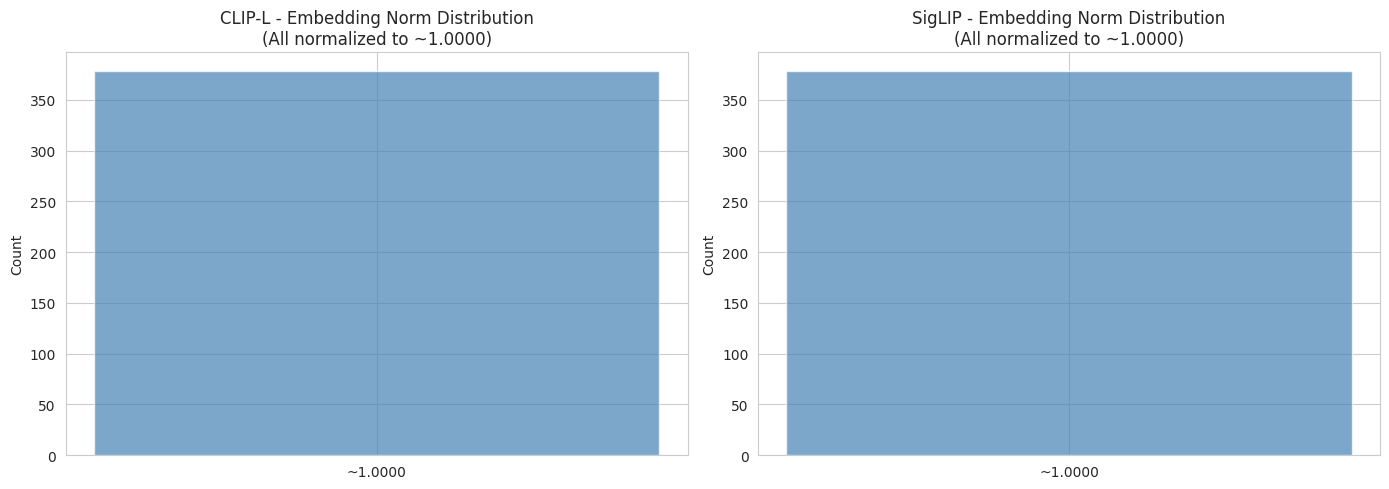

In [5]:
# ノルム分布のヒストグラム
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (emb, name) in zip(axes, [(clip_embeddings, "CLIP-L"), (siglip_embeddings, "SigLIP")]):
    norms = np.linalg.norm(emb, axis=1)
    
    # ノルムの範囲をチェック
    norm_range = norms.max() - norms.min()
    if norm_range < 1e-6:
        # ノルムがほぼ同じ値（正規化済み）の場合
        ax.bar([f"~{norms.mean():.4f}"], [len(norms)], color='steelblue', alpha=0.7)
        ax.set_ylabel("Count")
        ax.set_title(f"{name} - Embedding Norm Distribution\n(All normalized to ~{norms.mean():.4f})")
    else:
        # 通常のヒストグラム
        n_bins = min(50, max(10, int(norm_range / 0.001)))  # ビン数を適応的に設定
        ax.hist(norms, bins=n_bins, alpha=0.7, edgecolor='black')
        ax.axvline(norms.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {norms.mean():.4f}')
        ax.axvline(norms.min(), color='green', linestyle=':', label=f'Min: {norms.min():.4f}')
        ax.axvline(norms.max(), color='orange', linestyle=':', label=f'Max: {norms.max():.4f}')
        ax.set_xlabel("L2 Norm")
        ax.set_ylabel("Frequency")
        ax.set_title(f"{name} - Embedding Norm Distribution")
        ax.legend()

plt.tight_layout()
plt.savefig("../data/vector_space_norm_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

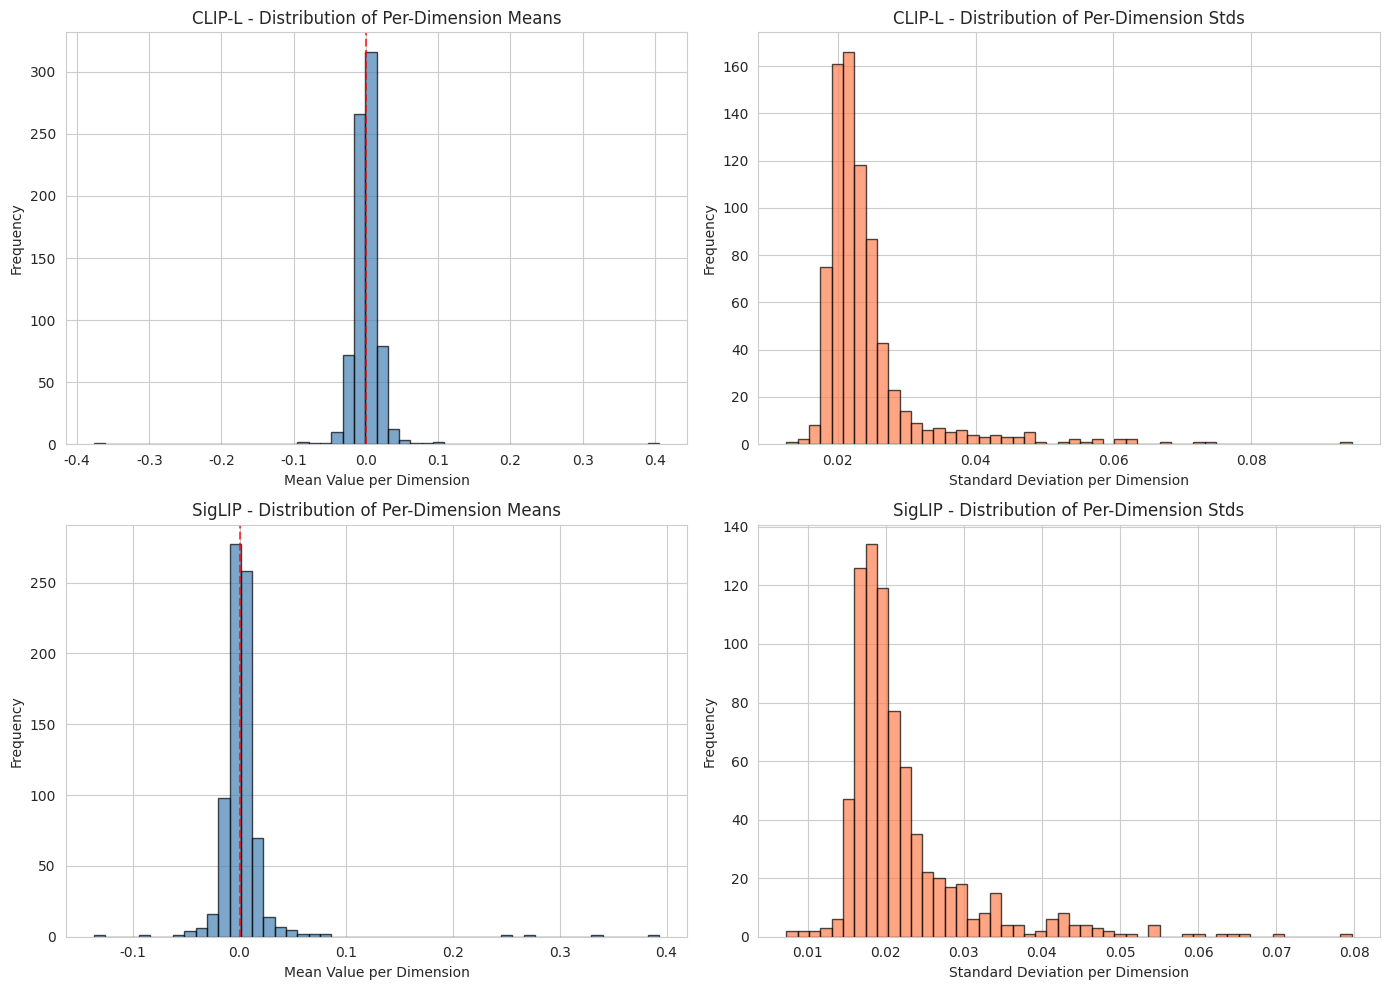

In [6]:
# 次元ごとの値分布
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (emb, name) in enumerate([(clip_embeddings, "CLIP-L"), (siglip_embeddings, "SigLIP")]):
    # 各次元の平均値分布
    dim_means = emb.mean(axis=0)
    axes[i, 0].hist(dim_means, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
    axes[i, 0].axvline(0, color='red', linestyle='--', alpha=0.7)
    axes[i, 0].set_xlabel("Mean Value per Dimension")
    axes[i, 0].set_ylabel("Frequency")
    axes[i, 0].set_title(f"{name} - Distribution of Per-Dimension Means")
    
    # 各次元の標準偏差分布
    dim_stds = emb.std(axis=0)
    axes[i, 1].hist(dim_stds, bins=50, alpha=0.7, edgecolor='black', color='coral')
    axes[i, 1].set_xlabel("Standard Deviation per Dimension")
    axes[i, 1].set_ylabel("Frequency")
    axes[i, 1].set_title(f"{name} - Distribution of Per-Dimension Stds")

plt.tight_layout()
plt.savefig("../data/vector_space_dim_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

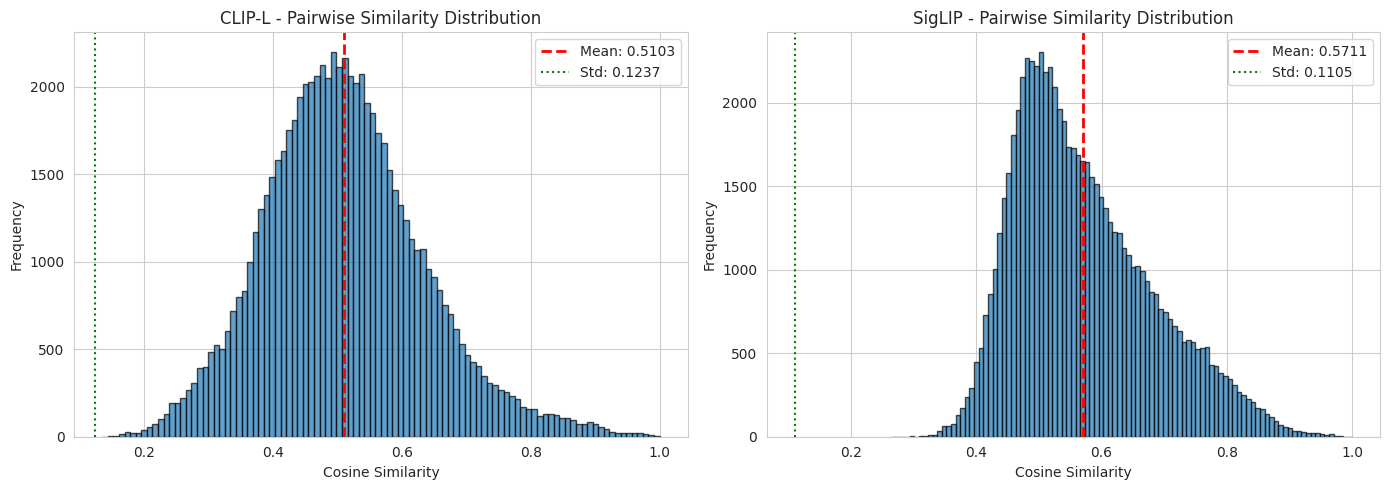

In [7]:
def compute_pairwise_similarity_sample(embeddings: np.ndarray, n_samples: int = 1000) -> np.ndarray:
    """メモリ効率のためサンプリングしてペアワイズ類似度を計算"""
    # 正規化
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / np.clip(norms, 1e-8, None)
    
    n = len(embeddings)
    if n <= n_samples:
        sim_matrix = np.dot(normalized, normalized.T)
        # 上三角部分のみ（対角線除く）
        return sim_matrix[np.triu_indices(n, k=1)]
    
    # サンプリング
    indices = np.random.choice(n, n_samples, replace=False)
    sampled = normalized[indices]
    sim_matrix = np.dot(sampled, sampled.T)
    return sim_matrix[np.triu_indices(n_samples, k=1)]

# ペアワイズ類似度分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (emb, name) in zip(axes, [(clip_embeddings, "CLIP-L"), (siglip_embeddings, "SigLIP")]):
    similarities = compute_pairwise_similarity_sample(emb)
    ax.hist(similarities, bins=100, alpha=0.7, edgecolor='black')
    ax.axvline(similarities.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {similarities.mean():.4f}')
    ax.axvline(similarities.std(), color='green', linestyle=':', 
               label=f'Std: {similarities.std():.4f}')
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{name} - Pairwise Similarity Distribution")
    ax.legend()

plt.tight_layout()
plt.savefig("../data/vector_space_pairwise_similarity.png", dpi=150, bbox_inches='tight')
plt.show()

## 2. 異方性(Anisotropy)の評価

In [8]:
def compute_anisotropy_metrics(embeddings: np.ndarray) -> dict:
    """異方性の評価指標を計算"""
    # 正規化
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized_emb = embeddings / np.clip(norms, 1e-8, None)
    
    # 平均ベクトル
    mean_vector = embeddings.mean(axis=0)
    mean_norm = np.linalg.norm(mean_vector)
    normalized_mean = mean_vector / np.clip(mean_norm, 1e-8, None)
    
    # 各ベクトルと平均ベクトルのコサイン類似度
    similarities_to_mean = np.dot(normalized_emb, normalized_mean)
    
    # 全ペアのコサイン類似度の平均（異方性指標）
    all_sims = compute_pairwise_similarity_sample(embeddings)
    
    return {
        "mean_vector_norm": mean_norm,
        "sim_to_mean_avg": similarities_to_mean.mean(),
        "sim_to_mean_std": similarities_to_mean.std(),
        "sim_to_mean_min": similarities_to_mean.min(),
        "sim_to_mean_max": similarities_to_mean.max(),
        "avg_pairwise_similarity": all_sims.mean(),
        "anisotropy_score": all_sims.mean(),  # 高いほど異方的
    }

clip_aniso = compute_anisotropy_metrics(clip_embeddings)
siglip_aniso = compute_anisotropy_metrics(siglip_embeddings)

aniso_df = pd.DataFrame([
    {"model": "CLIP-L", **clip_aniso},
    {"model": "SigLIP", **siglip_aniso}
]).set_index("model")

print("=" * 70)
print("異方性評価")
print("=" * 70)
print("\nanisotropy_score: 高いほど異方的（すべてのベクトルが似た方向を向いている）")
display(aniso_df.T.round(4))

異方性評価

anisotropy_score: 高いほど異方的（すべてのベクトルが似た方向を向いている）


model,CLIP-L,SigLIP
mean_vector_norm,0.7152,0.7565
sim_to_mean_avg,0.7152,0.7565
sim_to_mean_std,0.0690,0.0629
sim_to_mean_min,0.4401,0.5750
sim_to_mean_max,0.8415,0.8707
avg_pairwise_similarity,0.5103,0.5711
anisotropy_score,0.5103,0.5711


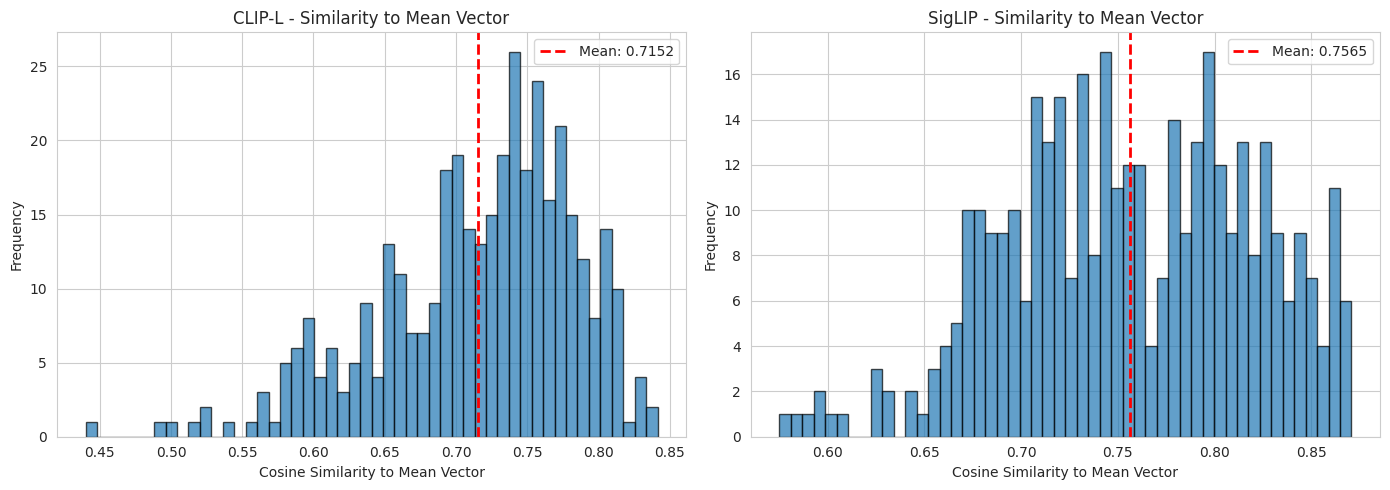

In [9]:
# 平均ベクトルからの類似度分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (emb, name) in zip(axes, [(clip_embeddings, "CLIP-L"), (siglip_embeddings, "SigLIP")]):
    # 正規化
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    normalized_emb = emb / np.clip(norms, 1e-8, None)
    
    mean_vector = emb.mean(axis=0)
    normalized_mean = mean_vector / np.linalg.norm(mean_vector)
    similarities = np.dot(normalized_emb, normalized_mean)
    
    ax.hist(similarities, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(similarities.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {similarities.mean():.4f}')
    ax.set_xlabel("Cosine Similarity to Mean Vector")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{name} - Similarity to Mean Vector")
    ax.legend()

plt.tight_layout()
plt.savefig("../data/vector_space_anisotropy.png", dpi=150, bbox_inches='tight')
plt.show()

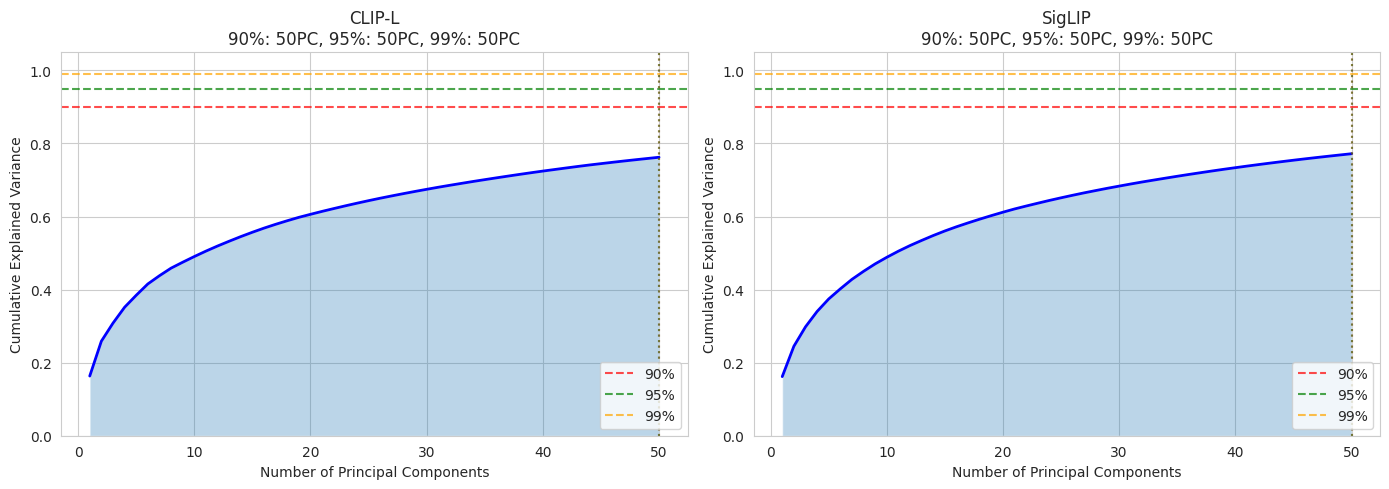


PCA Results:
  CLIP-L: 90% at 50PC, 95% at 50PC, 99% at 50PC
  SigLIP: 90% at 50PC, 95% at 50PC, 99% at 50PC


In [10]:
def analyze_pca_variance(embeddings: np.ndarray, n_components: int = 50) -> tuple:
    """PCA主成分の分散比率を分析"""
    pca = PCA(n_components=min(n_components, embeddings.shape[1]))
    pca.fit(embeddings)
    
    explained_var = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)
    
    # 90%, 95%, 99%に達するのに必要な主成分数
    n_90 = np.argmax(cumulative_var >= 0.9) + 1 if cumulative_var[-1] >= 0.9 else len(cumulative_var)
    n_95 = np.argmax(cumulative_var >= 0.95) + 1 if cumulative_var[-1] >= 0.95 else len(cumulative_var)
    n_99 = np.argmax(cumulative_var >= 0.99) + 1 if cumulative_var[-1] >= 0.99 else len(cumulative_var)
    
    return explained_var, cumulative_var, n_90, n_95, n_99

# PCA分散比率の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pca_results = {}
for ax, (emb, name) in zip(axes, [(clip_embeddings, "CLIP-L"), (siglip_embeddings, "SigLIP")]):
    var_ratio, cum_var, n_90, n_95, n_99 = analyze_pca_variance(emb)
    pca_results[name] = {"n_90": n_90, "n_95": n_95, "n_99": n_99}
    
    # 累積寄与率プロット
    x = range(1, len(cum_var) + 1)
    ax.plot(x, cum_var, 'b-', linewidth=2)
    ax.fill_between(x, cum_var, alpha=0.3)
    
    ax.axhline(0.9, color='r', linestyle='--', alpha=0.7, label='90%')
    ax.axhline(0.95, color='g', linestyle='--', alpha=0.7, label='95%')
    ax.axhline(0.99, color='orange', linestyle='--', alpha=0.7, label='99%')
    
    ax.axvline(n_90, color='r', linestyle=':', alpha=0.5)
    ax.axvline(n_95, color='g', linestyle=':', alpha=0.5)
    
    ax.set_xlabel("Number of Principal Components")
    ax.set_ylabel("Cumulative Explained Variance")
    ax.set_title(f"{name}\n90%: {n_90}PC, 95%: {n_95}PC, 99%: {n_99}PC")
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("../data/vector_space_pca_variance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nPCA Results:")
for name, res in pca_results.items():
    print(f"  {name}: 90% at {res['n_90']}PC, 95% at {res['n_95']}PC, 99% at {res['n_99']}PC")

In [11]:
def compute_intrinsic_dimensionality(embeddings: np.ndarray) -> dict:
    """内在次元性の指標を計算"""
    pca = PCA(n_components=min(100, embeddings.shape[1]))
    pca.fit(embeddings)
    
    var_ratio = pca.explained_variance_ratio_
    
    # 有効次元数（Participation Ratio）
    # PR = (Σλi)² / Σλi² - 高いほど次元が均等に使われている
    pr = (var_ratio.sum() ** 2) / (var_ratio ** 2).sum()
    
    # エントロピーベースの有効次元数
    var_norm = var_ratio / var_ratio.sum()
    entropy = -np.sum(var_norm * np.log(var_norm + 1e-10))
    effective_dim_entropy = np.exp(entropy)
    
    return {
        "participation_ratio": pr,
        "effective_dim_entropy": effective_dim_entropy,
        "top1_variance": var_ratio[0],
        "top5_variance": var_ratio[:5].sum(),
        "top10_variance": var_ratio[:10].sum(),
    }

clip_dim = compute_intrinsic_dimensionality(clip_embeddings)
siglip_dim = compute_intrinsic_dimensionality(siglip_embeddings)

dim_df = pd.DataFrame([
    {"model": "CLIP-L", **clip_dim},
    {"model": "SigLIP", **siglip_dim}
]).set_index("model")

print("=" * 70)
print("内在次元性分析")
print("=" * 70)
print("\nParticipation Ratio: 高いほど次元が均等に使われている（等方的）")
print("Effective Dim (Entropy): エントロピーベースの有効次元数")
display(dim_df.T.round(4))

内在次元性分析

Participation Ratio: 高いほど次元が均等に使われている（等方的）
Effective Dim (Entropy): エントロピーベースの有効次元数


model,CLIP-L,SigLIP
participation_ratio,16.846901,17.799000
effective_dim_entropy,40.264702,41.199699
top1_variance,0.163300,0.161800
top5_variance,0.384500,0.374400
top10_variance,0.490500,0.488400


## 3. 多言語テキストの意味的近傍性

In [12]:
# 多言語テストテキスト（同じ意味を複数言語で表現）
multilingual_texts = {
    "park": {
        "en": "a park with trees",
        "ja": "木々のある公園",
        "es": "un parque con árboles",
        "zh": "有树木的公园",
        "fr": "un parc avec des arbres",
        "de": "ein Park mit Bäumen",
        "ko": "나무가 있는 공원",
    },
    "night": {
        "en": "city lights at night",
        "ja": "夜の街明かり",
        "es": "luces de la ciudad de noche",
        "zh": "夜晚的城市灯光",
        "fr": "lumières de la ville la nuit",
        "de": "Stadtlichter in der Nacht",
        "ko": "밤의 도시 불빛",
    },
    "conference": {
        "en": "tech conference presentation",
        "ja": "技術カンファレンスの発表",
        "es": "presentación de conferencia tecnológica",
        "zh": "技术会议演讲",
        "fr": "présentation de conférence technique",
        "de": "Technologiekonferenz Präsentation",
        "ko": "기술 컨퍼런스 발표",
    },
    "portrait": {
        "en": "portrait of a person",
        "ja": "人物のポートレート",
        "es": "retrato de una persona",
        "zh": "人物肖像",
        "fr": "portrait d'une personne",
        "de": "Porträt einer Person",
        "ko": "사람의 초상화",
    },
    "nature": {
        "en": "beautiful natural scenery",
        "ja": "美しい自然の風景",
        "es": "hermoso paisaje natural",
        "zh": "美丽的自然风景",
        "fr": "beau paysage naturel",
        "de": "schöne Naturlandschaft",
        "ko": "아름다운 자연 풍경",
    },
}

LANGUAGES = ["en", "ja", "es", "zh", "fr", "de", "ko"]
CONCEPTS = list(multilingual_texts.keys())

print(f"Concepts: {CONCEPTS}")
print(f"Languages: {LANGUAGES}")
print(f"Total texts: {len(CONCEPTS) * len(LANGUAGES)}")

Concepts: ['park', 'night', 'conference', 'portrait', 'nature']
Languages: ['en', 'ja', 'es', 'zh', 'fr', 'de', 'ko']
Total texts: 35


In [13]:
# モデルロード
print("Loading CLIP-L...")
clip_embedder = CLIPEmbedder(model_name=CLIP_MODEL, device="cuda")
print(f"  Loaded: {clip_embedder.model_name}")

print("\nLoading SigLIP...")
siglip_embedder = SigLIPEmbedder(model_name=SIGLIP_MODEL, device="cuda")
print(f"  Loaded: {siglip_embedder.model_name}")

Loading CLIP-L...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


  Loaded: openai/clip-vit-large-patch14

Loading SigLIP...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


  Loaded: google/siglip-base-patch16-224


In [14]:
def embed_multilingual_texts(embedder, texts_dict: dict) -> tuple[np.ndarray, list, list]:
    """多言語テキストをembeddingに変換"""
    all_texts = []
    concepts = []
    languages = []
    
    for concept, lang_texts in texts_dict.items():
        for lang, text in lang_texts.items():
            all_texts.append(text)
            concepts.append(concept)
            languages.append(lang)
    
    embeddings = embedder.embed_texts(all_texts)
    return embeddings, concepts, languages

clip_text_emb, text_concepts, text_langs = embed_multilingual_texts(clip_embedder, multilingual_texts)
siglip_text_emb, _, _ = embed_multilingual_texts(siglip_embedder, multilingual_texts)

print(f"CLIP text embeddings: {clip_text_emb.shape}")
print(f"SigLIP text embeddings: {siglip_text_emb.shape}")

CLIP text embeddings: (35, 768)
SigLIP text embeddings: (35, 768)


In [15]:
def compute_cross_lingual_similarity(embeddings: np.ndarray, concepts: list, languages: list) -> dict:
    """言語間の類似度を分析"""
    # 正規化
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / np.clip(norms, 1e-8, None)
    
    # 類似度行列
    sim_matrix = np.dot(normalized, normalized.T)
    
    # 同概念・異言語ペアの類似度
    same_concept_diff_lang = []
    # 異概念・同言語ペアの類似度
    diff_concept_same_lang = []
    # 異概念・異言語ペアの類似度
    diff_concept_diff_lang = []
    
    n = len(embeddings)
    for i in range(n):
        for j in range(i + 1, n):
            same_concept = concepts[i] == concepts[j]
            same_lang = languages[i] == languages[j]
            sim = sim_matrix[i, j]
            
            if same_concept and not same_lang:
                same_concept_diff_lang.append(sim)
            elif not same_concept and same_lang:
                diff_concept_same_lang.append(sim)
            elif not same_concept and not same_lang:
                diff_concept_diff_lang.append(sim)
    
    return {
        "same_concept_diff_lang": np.array(same_concept_diff_lang),
        "diff_concept_same_lang": np.array(diff_concept_same_lang),
        "diff_concept_diff_lang": np.array(diff_concept_diff_lang),
    }

clip_cross = compute_cross_lingual_similarity(clip_text_emb, text_concepts, text_langs)
siglip_cross = compute_cross_lingual_similarity(siglip_text_emb, text_concepts, text_langs)

# 統計サマリー
print("=" * 70)
print("多言語テキスト類似度分析")
print("=" * 70)

for name, cross in [("CLIP-L", clip_cross), ("SigLIP", siglip_cross)]:
    print(f"\n{name}:")
    print(f"  同概念・異言語: mean={cross['same_concept_diff_lang'].mean():.4f}, std={cross['same_concept_diff_lang'].std():.4f}")
    print(f"  異概念・同言語: mean={cross['diff_concept_same_lang'].mean():.4f}, std={cross['diff_concept_same_lang'].std():.4f}")
    print(f"  異概念・異言語: mean={cross['diff_concept_diff_lang'].mean():.4f}, std={cross['diff_concept_diff_lang'].std():.4f}")

多言語テキスト類似度分析

CLIP-L:
  同概念・異言語: mean=0.7072, std=0.0886
  異概念・同言語: mean=0.7512, std=0.0922
  異概念・異言語: mean=0.6201, std=0.0789

SigLIP:
  同概念・異言語: mean=0.8611, std=0.0623
  異概念・同言語: mean=0.7729, std=0.0447
  異概念・異言語: mean=0.7180, std=0.0488


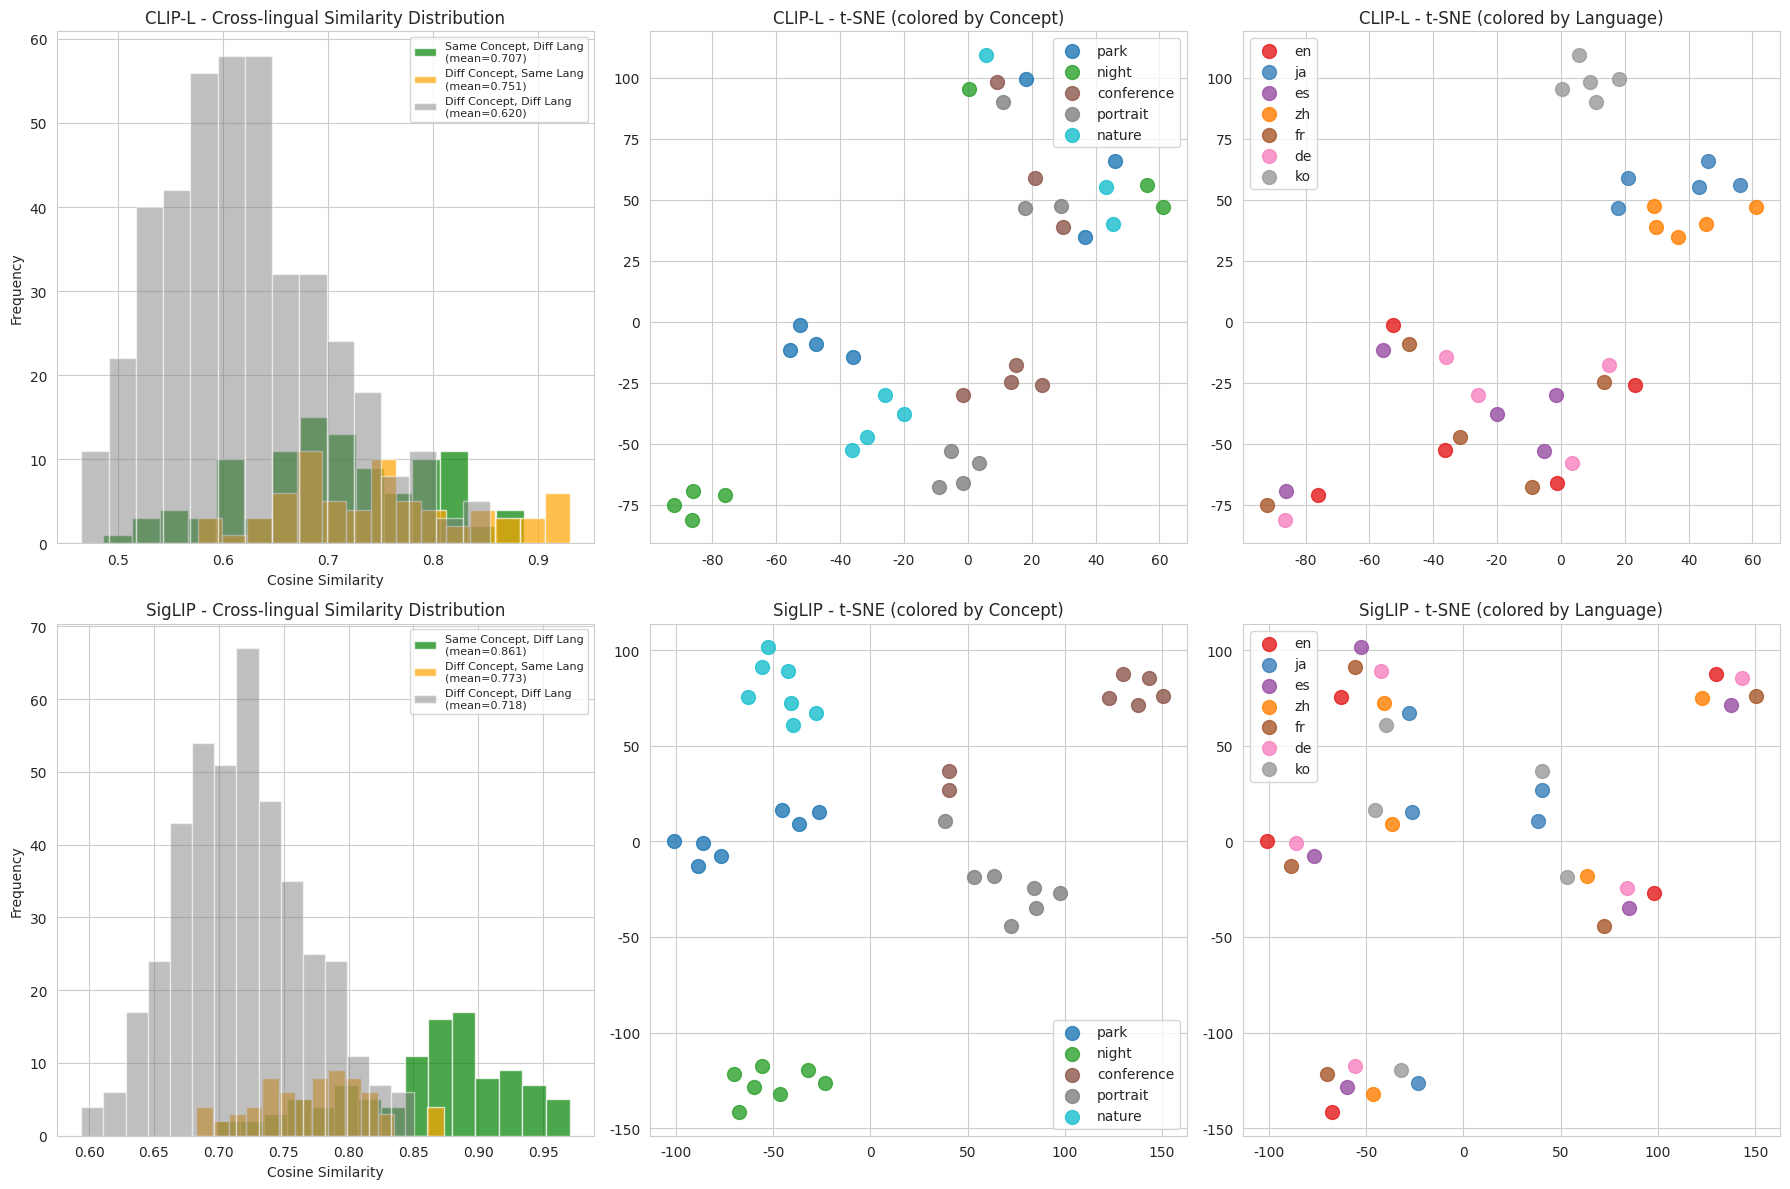

In [16]:
# 言語クラスタリング vs 意味クラスタリングの可視化
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for row, (emb, cross, name) in enumerate([
    (clip_text_emb, clip_cross, "CLIP-L"),
    (siglip_text_emb, siglip_cross, "SigLIP")
]):
    # 類似度分布比較
    ax = axes[row, 0]
    ax.hist(cross["same_concept_diff_lang"], bins=15, alpha=0.7, 
            label=f"Same Concept, Diff Lang\n(mean={cross['same_concept_diff_lang'].mean():.3f})", color='green')
    ax.hist(cross["diff_concept_same_lang"], bins=15, alpha=0.7, 
            label=f"Diff Concept, Same Lang\n(mean={cross['diff_concept_same_lang'].mean():.3f})", color='orange')
    ax.hist(cross["diff_concept_diff_lang"], bins=15, alpha=0.5, 
            label=f"Diff Concept, Diff Lang\n(mean={cross['diff_concept_diff_lang'].mean():.3f})", color='gray')
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{name} - Cross-lingual Similarity Distribution")
    ax.legend(fontsize=8)
    
    # t-SNE (概念で色分け)
    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=5)
    coords = tsne.fit_transform(emb)
    
    ax = axes[row, 1]
    colors = plt.cm.tab10(np.linspace(0, 1, len(CONCEPTS)))
    for idx, concept in enumerate(CONCEPTS):
        mask = np.array(text_concepts) == concept
        ax.scatter(coords[mask, 0], coords[mask, 1], label=concept, s=100, alpha=0.8, c=[colors[idx]])
    ax.set_title(f"{name} - t-SNE (colored by Concept)")
    ax.legend()
    
    # t-SNE (言語で色分け)
    ax = axes[row, 2]
    colors = plt.cm.Set1(np.linspace(0, 1, len(LANGUAGES)))
    for idx, lang in enumerate(LANGUAGES):
        mask = np.array(text_langs) == lang
        ax.scatter(coords[mask, 0], coords[mask, 1], label=lang, s=100, alpha=0.8, c=[colors[idx]])
    ax.set_title(f"{name} - t-SNE (colored by Language)")
    ax.legend()

plt.tight_layout()
plt.savefig("../data/vector_space_multilingual_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

In [17]:
def evaluate_clustering_tendency(embeddings: np.ndarray, concepts: list, languages: list) -> dict:
    """概念ベース vs 言語ベースのクラスタリング傾向を評価"""
    # シルエットスコア（概念でグループ化）
    sil_concept = silhouette_score(embeddings, concepts)
    
    # シルエットスコア（言語でグループ化）
    sil_language = silhouette_score(embeddings, languages)
    
    # クラスタリング傾向指標
    # > 0: 意味（概念）でクラスタリング
    # < 0: 言語でクラスタリング
    clustering_bias = sil_concept - sil_language
    
    return {
        "silhouette_by_concept": sil_concept,
        "silhouette_by_language": sil_language,
        "clustering_bias": clustering_bias,
        "tendency": "Semantic" if clustering_bias > 0 else "Linguistic",
    }

clip_cluster = evaluate_clustering_tendency(clip_text_emb, text_concepts, text_langs)
siglip_cluster = evaluate_clustering_tendency(siglip_text_emb, text_concepts, text_langs)

cluster_df = pd.DataFrame([
    {"model": "CLIP-L", **clip_cluster},
    {"model": "SigLIP", **siglip_cluster}
]).set_index("model")

print("=" * 70)
print("クラスタリング傾向分析")
print("=" * 70)
print("\nclustering_bias > 0: 意味（概念）ベースでクラスタリング")
print("clustering_bias < 0: 言語ベースでクラスタリング")
display(cluster_df)

クラスタリング傾向分析

clustering_bias > 0: 意味（概念）ベースでクラスタリング
clustering_bias < 0: 言語ベースでクラスタリング


,silhouette_by_concept,silhouette_by_language,clustering_bias,tendency
model,,,,
CLIP-L,0.056035,0.090269,-0.034234,Linguistic
SigLIP,0.248938,-0.033947,0.282885,Semantic


## 4. テキスト-画像間の近傍評価

In [18]:
def compute_text_image_similarity(text_emb: np.ndarray, image_emb: np.ndarray) -> np.ndarray:
    """テキストと画像間の類似度行列を計算"""
    # 正規化
    text_norm = text_emb / np.linalg.norm(text_emb, axis=1, keepdims=True)
    image_norm = image_emb / np.linalg.norm(image_emb, axis=1, keepdims=True)
    return np.dot(text_norm, image_norm.T)

clip_ti_sim = compute_text_image_similarity(clip_text_emb, clip_embeddings)
siglip_ti_sim = compute_text_image_similarity(siglip_text_emb, siglip_embeddings)

print(f"Text-Image similarity matrix shape: {clip_ti_sim.shape}")
print(f"  Rows: {len(text_concepts)} texts")
print(f"  Cols: {len(metadata)} images")

Text-Image similarity matrix shape: (35, 378)
  Rows: 35 texts
  Cols: 378 images


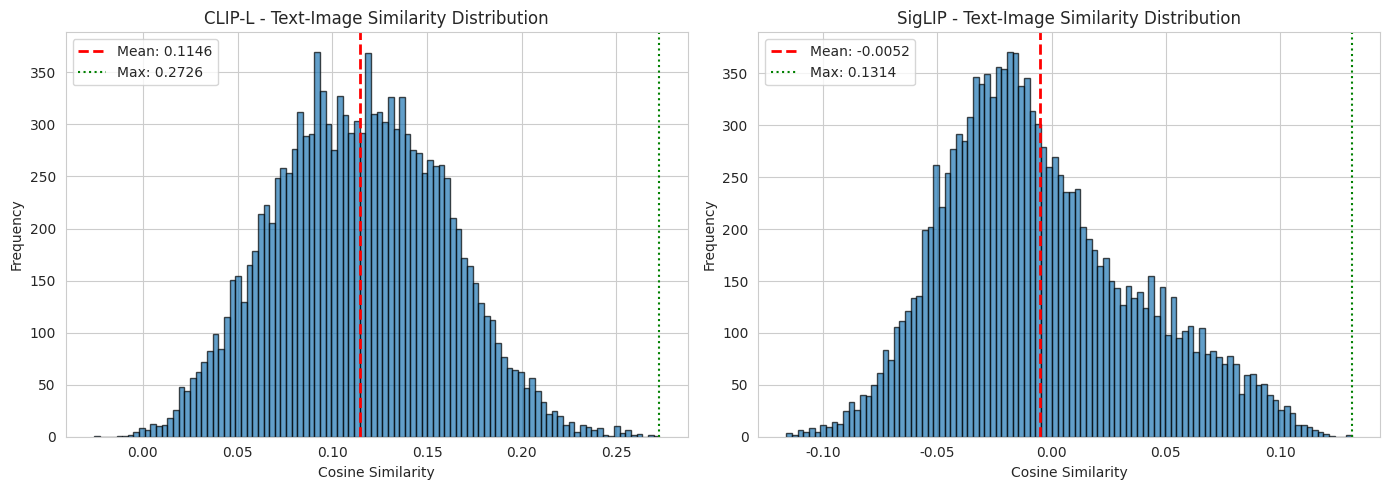

In [19]:
# テキスト-画像類似度の分布比較
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (sim, name) in zip(axes, [(clip_ti_sim, "CLIP-L"), (siglip_ti_sim, "SigLIP")]):
    all_sims = sim.flatten()
    ax.hist(all_sims, bins=100, alpha=0.7, edgecolor='black')
    ax.axvline(all_sims.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {all_sims.mean():.4f}')
    ax.axvline(all_sims.max(), color='green', linestyle=':', 
               label=f'Max: {all_sims.max():.4f}')
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{name} - Text-Image Similarity Distribution")
    ax.legend()

plt.tight_layout()
plt.savefig("../data/vector_space_text_image_similarity.png", dpi=150, bbox_inches='tight')
plt.show()

In [20]:
def compute_cross_modal_gap(text_emb: np.ndarray, image_emb: np.ndarray) -> dict:
    """クロスモーダルギャップの評価指標を計算"""
    # テキスト空間の平均ベクトル
    text_mean = text_emb.mean(axis=0)
    # 画像空間の平均ベクトル
    image_mean = image_emb.mean(axis=0)
    
    # 平均ベクトル間のコサイン類似度
    text_mean_norm = text_mean / np.linalg.norm(text_mean)
    image_mean_norm = image_mean / np.linalg.norm(image_mean)
    mean_similarity = np.dot(text_mean_norm, image_mean_norm)
    
    # 平均ベクトル間のユークリッド距離
    mean_distance = np.linalg.norm(text_mean - image_mean)
    
    # テキスト内の平均類似度
    text_sims = compute_pairwise_similarity_sample(text_emb, n_samples=100)
    avg_text_sim = text_sims.mean()
    
    # 画像内の平均類似度
    image_sims = compute_pairwise_similarity_sample(image_emb, n_samples=385)
    avg_image_sim = image_sims.mean()
    
    # テキスト-画像間の平均類似度
    ti_sim = compute_text_image_similarity(text_emb, image_emb)
    avg_ti_sim = ti_sim.mean()
    
    return {
        "mean_vector_similarity": mean_similarity,
        "mean_vector_distance": mean_distance,
        "avg_intra_text_similarity": avg_text_sim,
        "avg_intra_image_similarity": avg_image_sim,
        "avg_cross_modal_similarity": avg_ti_sim,
        "modality_gap": (avg_text_sim + avg_image_sim) / 2 - avg_ti_sim,
    }

clip_gap = compute_cross_modal_gap(clip_text_emb, clip_embeddings)
siglip_gap = compute_cross_modal_gap(siglip_text_emb, siglip_embeddings)

gap_df = pd.DataFrame([
    {"model": "CLIP-L", **clip_gap},
    {"model": "SigLIP", **siglip_gap}
]).set_index("model")

print("=" * 70)
print("クロスモーダルギャップ分析")
print("=" * 70)
print("\nmodality_gap: テキスト/画像内類似度とクロスモーダル類似度の差")
print("小さいほどテキストと画像が同じ空間に配置されている")
display(gap_df.T.round(4))

クロスモーダルギャップ分析

modality_gap: テキスト/画像内類似度とクロスモーダル類似度の差
小さいほどテキストと画像が同じ空間に配置されている


model,CLIP-L,SigLIP
mean_vector_similarity,0.1972,-0.0079
mean_vector_distance,0.9712,1.1574
avg_intra_text_similarity,0.6509,0.7497
avg_intra_image_similarity,0.5103,0.5711
avg_cross_modal_similarity,0.1146,-0.0052
modality_gap,0.4660,0.6656


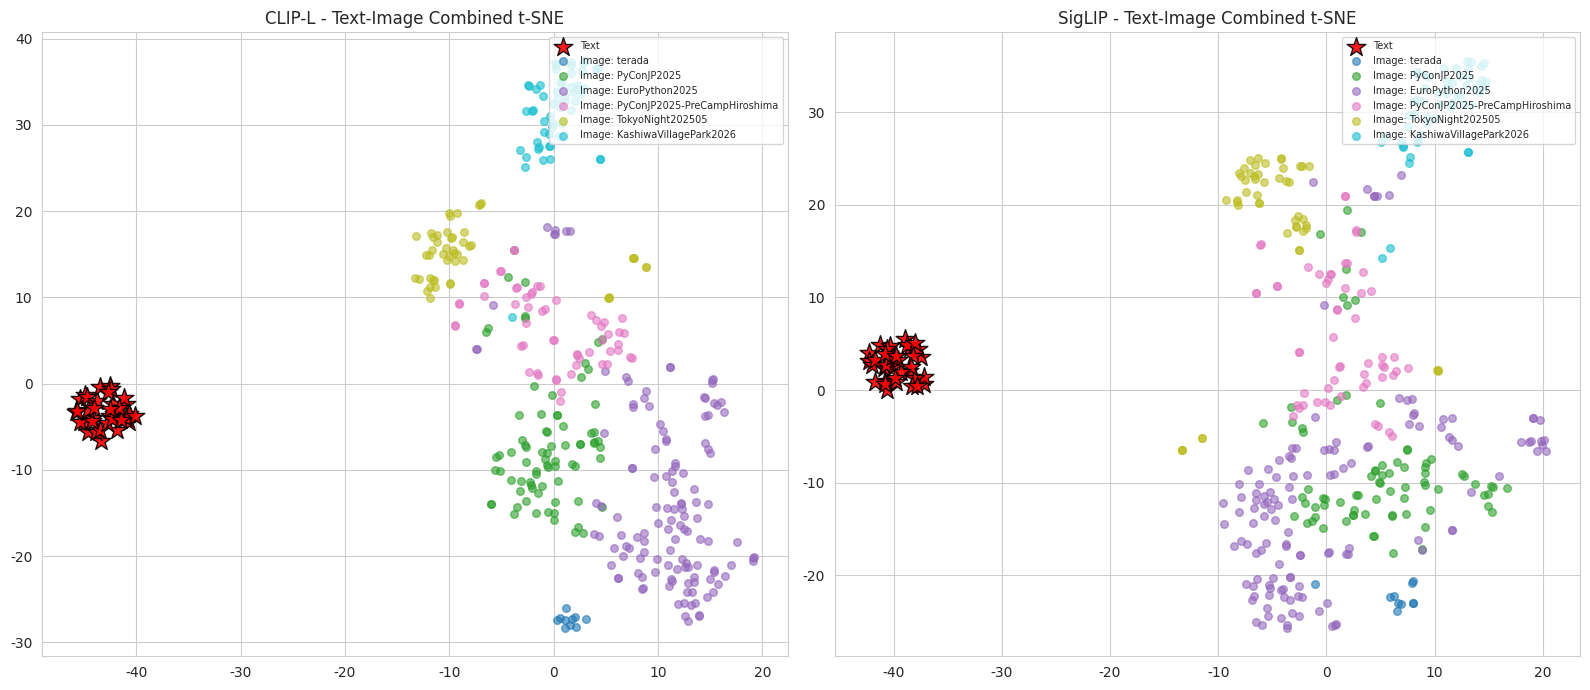

In [21]:
# テキスト-画像の統合可視化
combined_clip = np.vstack([clip_text_emb, clip_embeddings])
combined_siglip = np.vstack([siglip_text_emb, siglip_embeddings])

n_texts = len(clip_text_emb)
modality_labels = ["text"] * n_texts + ["image"] * len(clip_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (emb, name) in zip(axes, [(combined_clip, "CLIP-L"), (combined_siglip, "SigLIP")]):
    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
    coords = tsne.fit_transform(emb)
    
    # テキスト
    text_mask = np.array(modality_labels) == "text"
    ax.scatter(coords[text_mask, 0], coords[text_mask, 1], 
               c='red', marker='*', s=200, label='Text', alpha=0.9, edgecolors='black')
    
    # 画像（カテゴリで色分け）
    categories_list = metadata["category"].tolist()
    unique_cats = metadata["category"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
    
    for cat, color in zip(unique_cats, colors):
        cat_mask = np.array(categories_list) == cat
        full_mask = np.zeros(len(emb), dtype=bool)
        full_mask[n_texts:] = cat_mask
        ax.scatter(coords[full_mask, 0], coords[full_mask, 1], 
                   c=[color], marker='o', s=30, label=f'Image: {cat}', alpha=0.6)
    
    ax.set_title(f"{name} - Text-Image Combined t-SNE")
    ax.legend(loc='upper right', fontsize=7)

plt.tight_layout()
plt.savefig("../data/vector_space_text_image_tsne.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. 総合分析とまとめ

In [22]:
print("=" * 70)
print("実験25: ベクトル空間分析 - 総合サマリー")
print("=" * 70)

# 統合サマリーテーブル
summary_data = {
    "指標": [
        "Embedding次元数",
        "ノルム平均",
        "ペアワイズ類似度平均（異方性）",
        "Participation Ratio（次元利用効率）",
        "多言語クラスタリング傾向",
        "意味ベースシルエットスコア",
        "言語ベースシルエットスコア",
        "クロスモーダルギャップ",
        "テキスト-画像平均類似度",
    ],
    "CLIP-L": [
        768,
        f"{clip_stats['norm_mean']:.4f}",
        f"{clip_aniso['anisotropy_score']:.4f}",
        f"{clip_dim['participation_ratio']:.2f}",
        clip_cluster["tendency"],
        f"{clip_cluster['silhouette_by_concept']:.4f}",
        f"{clip_cluster['silhouette_by_language']:.4f}",
        f"{clip_gap['modality_gap']:.4f}",
        f"{clip_gap['avg_cross_modal_similarity']:.4f}",
    ],
    "SigLIP": [
        768,
        f"{siglip_stats['norm_mean']:.4f}",
        f"{siglip_aniso['anisotropy_score']:.4f}",
        f"{siglip_dim['participation_ratio']:.2f}",
        siglip_cluster["tendency"],
        f"{siglip_cluster['silhouette_by_concept']:.4f}",
        f"{siglip_cluster['silhouette_by_language']:.4f}",
        f"{siglip_gap['modality_gap']:.4f}",
        f"{siglip_gap['avg_cross_modal_similarity']:.4f}",
    ],
}

summary_df = pd.DataFrame(summary_data).set_index("指標")
display(summary_df)

実験25: ベクトル空間分析 - 総合サマリー


,CLIP-L,SigLIP
指標,,
Embedding次元数,768,768
ノルム平均,1.0000,1.0000
ペアワイズ類似度平均（異方性）,0.5103,0.5711
Participation Ratio（次元利用効率）,16.85,17.80
多言語クラスタリング傾向,Linguistic,Semantic
意味ベースシルエットスコア,0.0560,0.2489
言語ベースシルエットスコア,0.0903,-0.0339
クロスモーダルギャップ,0.4660,0.6656
テキスト-画像平均類似度,0.1146,-0.0052


In [23]:
# 結果の保存
def convert_to_serializable(obj):
    """NumPy型をPython標準型に変換"""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    return obj

output_data = {
    "timestamp": datetime.now().isoformat(),
    "models": [CLIP_MODEL, SIGLIP_MODEL],
    "distribution_stats": {
        "CLIP-L": convert_to_serializable(clip_stats),
        "SigLIP": convert_to_serializable(siglip_stats),
    },
    "anisotropy": {
        "CLIP-L": convert_to_serializable(clip_aniso),
        "SigLIP": convert_to_serializable(siglip_aniso),
    },
    "intrinsic_dimensionality": {
        "CLIP-L": convert_to_serializable(clip_dim),
        "SigLIP": convert_to_serializable(siglip_dim),
    },
    "multilingual_clustering": {
        "CLIP-L": convert_to_serializable(clip_cluster),
        "SigLIP": convert_to_serializable(siglip_cluster),
    },
    "cross_modal_gap": {
        "CLIP-L": convert_to_serializable(clip_gap),
        "SigLIP": convert_to_serializable(siglip_gap),
    },
}

output_path = Path("../data/evaluations") / f"vector_space_analysis_{datetime.now().strftime('%Y-%m-%d')}.json"
with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/vector_space_analysis_2026-02-03.json


## 評価と考察

### 1. ベクトル空間の基本特性

#### 1.1 分布統計

| 指標 | CLIP-L | SigLIP | 解釈 |
|------|--------|--------|------|
| 次元数 | 768 | 768 | 同一 |
| ノルム | 1.0 (正規化済) | 1.0 (正規化済) | 単位球面上に配置 |
| 値範囲 | -0.49 〜 +0.53 | -0.26 〜 +0.48 | CLIP-Lの方が広い |
| 歪度 | 0.44 | **3.78** | SigLIPは正に偏った分布 |
| 尖度 | **42.5** | 37.5 | 両モデルとも尖った分布（正規分布は3） |

**考察**:
- 両モデルとも**単位球面上に正規化**されており、コサイン類似度での比較に適している
- CLIP-Lは値の分布がより対称的（歪度≈0）
- SigLIPは正の値に偏った分布を持つ（歪度=3.78）
- 高い尖度は、多くの次元が0に近い値を持ち、一部の次元のみが活性化することを示唆

#### 1.2 次元ごとの分散

| 指標 | CLIP-L | SigLIP |
|------|--------|--------|
| 次元平均の平均 | 0.0001 | 0.0023 |
| 次元平均の標準偏差 | 0.026 | 0.027 |
| 次元標準偏差の平均 | 0.024 | 0.022 |

- 両モデルとも次元間の分散は似通っている
- 各次元がほぼ均等に情報を持っている

---

### 2. 異方性（Anisotropy）の評価

| 指標 | CLIP-L | SigLIP | 理想値 |
|------|--------|--------|--------|
| 平均ベクトルノルム | 0.715 | **0.756** | 0に近いほど等方的 |
| 平均との類似度 | 0.715 | **0.756** | 0に近いほど等方的 |
| ペアワイズ類似度平均 | 0.510 | **0.571** | 0に近いほど等方的 |

**重要な発見**:
- **両モデルとも高い異方性を示す**（理想は0に近い値）
- SigLIPの方がより異方的（ベクトルが似た方向を向いている）
- これは、ベクトル空間の一部の領域にデータが集中していることを意味する

**異方性が高いことの影響**:
1. **検索精度への影響**: 類似度スコアの分布が狭くなり、微細な差異の検出が困難
2. **クラスタリングへの影響**: 異なるカテゴリが重なりやすくなる
3. **スケーラビリティへの影響**: データ量が増えると類似度の分離が難しくなる

---

### 3. 内在次元性（Intrinsic Dimensionality）

| 指標 | CLIP-L | SigLIP | 解釈 |
|------|--------|--------|------|
| Participation Ratio | 16.8 | **17.8** | 有効次元数（高いほど均等） |
| エントロピー有効次元 | 40.3 | **41.2** | 情報が分散している次元数 |
| Top-1 分散比率 | 16.3% | 16.2% | 第1主成分の寄与率 |
| Top-5 分散比率 | 38.4% | 37.4% | 上位5成分の累積寄与率 |
| Top-10 分散比率 | 49.0% | 48.8% | 上位10成分の累積寄与率 |

**考察**:
- 768次元中、実質的に使われているのは**約17〜41次元**
- **上位10次元で約50%の分散**を説明 → 次元削減の余地あり
- SigLIPの方がわずかに次元を有効活用している

**検討課題**:
- 次元削減（PCA/UMAP）による検索高速化の可能性
- ただし、残りの50%の情報も検索精度に寄与している可能性

---

### 4. 多言語テキストのクラスタリング傾向（最重要）

| 指標 | CLIP-L | SigLIP | 解釈 |
|------|--------|--------|------|
| 概念シルエット | 0.056 | **0.249** | 同じ概念がまとまる度合い |
| 言語シルエット | **0.090** | -0.034 | 同じ言語がまとまる度合い |
| クラスタリングバイアス | -0.034 | **+0.283** | 正=意味ベース、負=言語ベース |
| **傾向** | **言語ベース** | **意味ベース** | |

**これは本実験の最も重要な発見である**:

#### CLIP-L: 言語ベースのクラスタリング
- 同じ言語のテキストが近くに配置される
- 「park」(英語) と「公園」(日本語) は離れた位置
- 英語・ラテン系言語で高い検索性能を発揮する理由

#### SigLIP: 意味ベースのクラスタリング
- 同じ概念を表すテキストが言語に関係なく近くに配置
- 「park」(英語) と「公園」(日本語) が近い位置
- 多言語検索で高い性能を発揮する理由

**実験24の結果との整合性**:
| 言語 | CLIP-L MRR | SigLIP MRR | 理由 |
|------|------------|------------|------|
| 英語 | **0.91** | 0.85 | CLIP-Lは英語で学習 |
| 日本語 | 0.60 | **0.81** | SigLIPは意味ベース |
| 韓国語 | 0.38 | **0.82** | SigLIPは意味ベース |

---

### 5. クロスモーダルギャップ（テキスト-画像間の距離）

| 指標 | CLIP-L | SigLIP | 理想値 |
|------|--------|--------|--------|
| テキスト内平均類似度 | 0.651 | **0.750** | - |
| 画像内平均類似度 | 0.510 | 0.571 | - |
| **テキスト-画像類似度** | **0.115** | -0.005 | 高いほど良い |
| **モダリティギャップ** | **0.466** | 0.666 | 低いほど良い |

**重要な発見**:
- **CLIP-L**: テキストと画像が同じ空間に配置されている（類似度=0.115）
- **SigLIP**: テキストと画像が**ほぼ直交**している（類似度≈0）

**これが意味すること**:
1. CLIP-Lはテキスト-画像検索のために設計された空間構造を持つ
2. SigLIPは意味的クラスタリングを優先し、モダリティ間の直接比較は想定外の可能性
3. SigLIPでテキスト検索が機能するのは、**相対的なランキング**が正しいため

---

### 6. モデル特性の総合比較

| 観点 | CLIP-L | SigLIP | テキスト検索への影響 |
|------|--------|--------|---------------------|
| 異方性 | 中程度 (0.51) | やや高い (0.57) | △ 類似度分布が狭くなる |
| 有効次元 | 16.8 | 17.8 | ○ 情報量は十分 |
| クラスタリング | 言語ベース | **意味ベース** | SigLIPが多言語に強い |
| モダリティギャップ | **小さい** | 大きい | CLIP-Lが設計意図に合致 |
| 値分布 | 対称 | 正に偏り | 検索には大きな影響なし |

---

### 7. 今後の検討課題

#### 7.1 異方性への対応
- **問題**: 両モデルとも高い異方性を持ち、類似度分布が狭い
- **対策案**:
  1. **Whitening（白色化）**: 分散を均等化する変換
  2. **Isotropy Enhancement**: 異方性を軽減する後処理
  3. **Fine-tuning**: 特定ドメインでの追加学習

#### 7.2 次元削減の検討
- **現状**: 768次元中、実質17〜41次元のみ有効
- **対策案**:
  1. **PCA/SVD**: 上位50〜100次元に削減（検索高速化）
  2. **量子化**: 8bit/4bit量子化でメモリ削減
  3. **トレードオフ**: 精度低下の許容範囲を要検証

#### 7.3 多言語対応の戦略
- **現状**: CLIP-Lは言語ベース、SigLIPは意味ベース
- **対策案**:
  1. **言語による使い分け**: 英語→CLIP-L、日本語→SigLIP
  2. **アンサンブル**: 両モデルのスコアを統合
  3. **翻訳パイプライン**: 非英語クエリを英語に翻訳してCLIP-Lで検索

#### 7.4 クロスモーダルギャップへの対応
- **現状**: SigLIPはテキスト-画像類似度がほぼ0
- **検討事項**:
  1. SigLIPの検索が機能する理由の詳細調査
  2. 絶対的な類似度スコアを使う用途では要注意
  3. ランキングベースの評価では問題なし

---

### 8. 結論

本実験により、CLIP-LとSigLIPのベクトル空間構造の本質的な違いが明らかになった。

| 特性 | CLIP-L | SigLIP |
|------|--------|--------|
| **設計思想** | テキスト-画像の直接対応 | 意味的クラスタリング |
| **言語対応** | 英語中心 | 多言語対応 |
| **最適用途** | 英語テキスト検索、モダリティ間検索 | 多言語検索、意味的検索 |

> **ベクトル空間の構造を理解することで、モデル選択とシステム設計の根拠が得られた。用途に応じた適切なモデル選択が、検索システムの性能を最大化する鍵となる。**

---

### 注記：数値の根拠

| 分析項目 | データソース |
|----------|------------|
| 基本統計量 | 378枚の画像埋め込みベクトル |
| 異方性 | ペアワイズコサイン類似度 |
| 内在次元性 | PCA分散比率 |
| 多言語クラスタリング | 35テキスト（5概念×7言語）のシルエットスコア |
| クロスモーダルギャップ | テキスト埋め込みと画像埋め込みの類似度 |